Reference : https://github.com/open-thought/tiny-grpo/tree/main

In [ ]:
# !pip install nvidia-cuda-nvcc-cu11
# !pip install -U triton

In [1]:
import dataclasses
from typing import Tuple, Any, List, Dict
import math
import os
import copy

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
from fastprogress import progress_bar as pb
import datasets
from datasets import load_dataset
import transformers
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM, BitsAndBytesConfig, GenerationConfig
import einops
from PIL import Image
import bitsandbytes as bnb

import warnings
warnings.simplefilter('ignore')

os.environ['TOKENIZERS_PARALLELISM'] = 'false'

## 1. Configs

In [2]:
N_EPOCHS = 1
TRAIN_BATCH_SIZE = TEST_BATCH_SIZE = 2#16#8#32
LR = 5e-6
WEIGHT_DECAY = 1e-2
USE_AMP = False#True
# AMP_DTYPE = torch.float16
# dtype = torch.float16
# llm_dtype = torch.float16
AMP_DTYPE = torch.bfloat16
dtype = torch.bfloat16
llm_dtype = torch.bfloat16

model_id = "Qwen/Qwen2-0.5B-Instruct-AWQ"

# loss params
kl_weight = 0.01
clip_eps = 0.2

# rollout params
max_length = 1024
top_p = 1.0
temperature = 1.0

group_size = 5#12  # the number of text generations per prompt
rollouts_per_step = 32
epochs_per_step = 1
max_norm = 1.0  # gradient clipping

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## 2. Load LLM Tokenizer

In [4]:
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)

In [5]:
tokenizer.eos_token_id, tokenizer.pad_token_id

(151645, 151643)

In [6]:
# pad_token_id = tokenizer.eos_token_id
pad_token_id = tokenizer.pad_token_id

## 3. Prepare Dataset

In [7]:
dataset_id = "Jiayi-Pan/Countdown-Tasks-3to4"
hf_dataset = load_dataset(dataset_id, split="train")

In [8]:
hf_dataset

Dataset({
    features: ['target', 'nums'],
    num_rows: 490364
})

In [9]:
# hf_dataset_sampled = hf_dataset
hf_dataset_sampled = hf_dataset.shuffle().select(range(10000))

In [10]:
hf_dataset_sampled

Dataset({
    features: ['target', 'nums'],
    num_rows: 10000
})

In [11]:
def preprocess_data(numbers, target):
    r1_prefix = [{
        "role": "system",
        "content": "You are a helpful assistant. You first thinks about the reasoning process in the mind and then provides the user with the answer."
      },
      { 
        "role": "user",
        "content": f"Using the numbers {numbers}, create an equation that equals {target}. You can use basic arithmetic operations (+, -, *, /) and each number can only be used once. Show your work in <think> </think> tags. And return the final equation and answer in <answer> </answer> tags, for example <answer> (1 + 2) / 3 = 1 </answer>."
      },
      {
        "role": "assistant",
        "content": "Let me solve this step by step.\n<think>"
      }]
    return {"prompt": tokenizer.apply_chat_template(r1_prefix, tokenize=False, continue_final_message=True), "target": target}

def collate_fn(examples):
    target = torch.tensor([example["target"] for example in examples], dtype=torch.long)
    nums = [example["nums"] for example in examples]
    prompt = [example["prompt"] for example in examples]

    return {
        "target": target,
        "nums": nums,
        'prompt': prompt,
    }

In [12]:
%%time
hf_dataset_sampled = hf_dataset_sampled.map(lambda x: preprocess_data(x["nums"], x["target"]))

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

CPU times: user 1.09 s, sys: 63.2 ms, total: 1.15 s
Wall time: 1.08 s


In [13]:
hf_dataset_sampled[0]

{'target': 15,
 'nums': [55, 64, 6],
 'prompt': '<|im_start|>system\nYou are a helpful assistant. You first thinks about the reasoning process in the mind and then provides the user with the answer.<|im_end|>\n<|im_start|>user\nUsing the numbers [55, 64, 6], create an equation that equals 15. You can use basic arithmetic operations (+, -, *, /) and each number can only be used once. Show your work in <think> </think> tags. And return the final equation and answer in <answer> </answer> tags, for example <answer> (1 + 2) / 3 = 1 </answer>.<|im_end|>\n<|im_start|>assistant\nLet me solve this step by step.\n<think>'}

In [14]:
hf_dataset_sampled = hf_dataset_sampled.train_test_split(test_size=0.1, shuffle=True)

In [15]:
train_rollout_dataloader = torch.utils.data.DataLoader(
    hf_dataset_sampled['train'],
    shuffle=True,
    collate_fn=collate_fn,
    batch_size=rollouts_per_step,
)
test_dataloader = torch.utils.data.DataLoader(
    hf_dataset_sampled['test'],
    shuffle=False,
    collate_fn=collate_fn,
    batch_size=TEST_BATCH_SIZE,
)

In [16]:
_batch = next(iter(test_dataloader))

In [17]:
_batch

{'target': tensor([71, 28]),
 'nums': [[29, 78, 16, 91], [24, 31, 87, 37]],
 'prompt': ['<|im_start|>system\nYou are a helpful assistant. You first thinks about the reasoning process in the mind and then provides the user with the answer.<|im_end|>\n<|im_start|>user\nUsing the numbers [29, 78, 16, 91], create an equation that equals 71. You can use basic arithmetic operations (+, -, *, /) and each number can only be used once. Show your work in <think> </think> tags. And return the final equation and answer in <answer> </answer> tags, for example <answer> (1 + 2) / 3 = 1 </answer>.<|im_end|>\n<|im_start|>assistant\nLet me solve this step by step.\n<think>',
  '<|im_start|>system\nYou are a helpful assistant. You first thinks about the reasoning process in the mind and then provides the user with the answer.<|im_end|>\n<|im_start|>user\nUsing the numbers [24, 31, 87, 37], create an equation that equals 28. You can use basic arithmetic operations (+, -, *, /) and each number can only be 

## 4. GRPO Utils

### Experience Buffer

In [18]:
from dataclasses import dataclass, fields
from typing import Optional

import torch
import torch.nn.functional as F


def zero_pad_sequences(
    sequences: list[torch.Tensor], side: str = "left"
) -> torch.Tensor:
    assert side in ("left", "right")
    max_len = max(seq.size(0) for seq in sequences)
    padded_sequences = []
    for seq in sequences:
        pad_len = max_len - seq.size(0)
        padding = (pad_len, 0) if side == "left" else (0, pad_len)
        padded_sequences.append(F.pad(seq, padding))
    return torch.stack(padded_sequences, dim=0)


@dataclass
class Experience:
    sequences: torch.Tensor
    action_log_probs: torch.Tensor
    log_probs_ref: torch.Tensor
    returns: Optional[torch.Tensor]
    advantages: Optional[torch.Tensor]
    attention_mask: Optional[torch.Tensor]
    action_mask: torch.Tensor
    kl: Optional[torch.Tensor] = None

    def to(self, device: torch.device) -> 'Experience':
        members = {}
        for field in fields(self):
            v = getattr(self, field.name)
            if isinstance(v, torch.Tensor):
                v = v.to(device=device)
            members[field.name] = v
        return Experience(**members)


def split_experience_batch(experience: Experience) -> list[Experience]:
    batch_size = experience.sequences.size(0)
    batch_data = [{} for _ in range(batch_size)]
    keys = (
        "sequences",
        "action_log_probs",
        "log_probs_ref",
        "returns",
        "advantages",
        "attention_mask",
        "action_mask",
    )
    for key in keys:
        value = getattr(experience, key)
        if value is None:
            vals = [None] * batch_size
        else:
            vals = torch.unbind(value)
        assert batch_size == len(vals), (key, batch_size, len(vals))
        for i, v in enumerate(vals):
            batch_data[i][key] = v

    return [Experience(**data) for data in batch_data]


def join_experience_batch(items: list[Experience]) -> Experience:
    batch_data = {}
    keys = (
        "sequences",
        "action_log_probs",
        "log_probs_ref",
        "returns",
        "advantages",
        "attention_mask",
        "action_mask",
    )
    for key in keys:
        vals = [getattr(item, key) for item in items]
        if all(v is not None for v in vals):
            data = zero_pad_sequences(vals, "left")
        else:
            data = None
        batch_data[key] = data
    return Experience(**batch_data)


class ReplayBuffer:
    def __init__(self, limit: int = 0) -> None:
        self.limit = limit
        self.items: list[Experience] = []

    def append(self, experience: Experience) -> None:
        items = split_experience_batch(experience)
        self.items.extend(items)
        if self.limit > 0:
            samples_to_remove = len(self.items) - self.limit
            if samples_to_remove > 0:
                self.items = self.items[samples_to_remove:]

    def clear(self) -> None:
        self.items.clear()

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, idx: int) -> Experience:
        return self.items[idx]

### Traning Utils

In [19]:
@torch.inference_mode()
def rollout(
    model,
    tokenizer,
    prompt: str,
    num_rollouts: int,
    reward_fn_list,
    max_length: int = 1024,
    temperature: float = 1.0,
    top_p: float = 1.0,
) -> tuple[torch.Tensor, torch.Tensor, list[str]]:
    model.eval()

    # 1. tokenize prompt
    model_inputs = tokenizer(
        [prompt],
        return_tensors="pt",
        padding=True,
        padding_side="left",
        return_attention_mask=True,
    ).to(device)
    # duplicate prompt num_rollouts times
    model_inputs["attention_mask"] = model_inputs["attention_mask"].repeat(
        num_rollouts, 1
    )
    input_ids = model_inputs["input_ids"].repeat(num_rollouts, 1)
    model_inputs["input_ids"] = input_ids

    # 2. sample completions
    generation_config = GenerationConfig(
        do_sample=True,
        top_p=top_p,
        temperature=temperature,
        max_length=max_length,
        pad_token_id=pad_token_id,
    )
    sequence_ids = model.generate(**model_inputs, generation_config=generation_config)
    completions = tokenizer.batch_decode(
        sequence_ids[:, input_ids.shape[1]:], skip_special_tokens=True
    )

    action_mask = torch.zeros_like(sequence_ids, dtype=torch.bool)
    action_mask[:, input_ids.shape[1] :] = True
    action_mask[sequence_ids == pad_token_id] = False
    action_mask = action_mask[:, 1:]

    # 3. determine rewards
    rewards = torch.tensor(
        [sum([reward_fn(completion) for reward_fn in reward_fn_list]) for completion in completions],
        dtype=torch.float
    ).unsqueeze(-1)  # (num_rollouts, 1)

    return sequence_ids, rewards.to(sequence_ids.device), action_mask, completions


def group_advantages(rewards: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    return (rewards - rewards.mean()) / (rewards.std() + eps)


def sequence_log_probs_from_logits(
    logits: torch.tensor, output_ids: torch.tensor
) -> torch.Tensor:
    log_prob = F.log_softmax(logits, dim=-1)
    return log_prob.gather(dim=-1, index=output_ids.unsqueeze(-1)).squeeze(-1)


def sequences_log_probs(
    model,
    sequence_ids: torch.Tensor,
    attention_mask: torch.Tensor,
) -> torch.Tensor:
    position_ids = attention_mask.long().cumsum(dim=-1) - 1
    position_ids.masked_fill_(mask=(attention_mask == 0), value=1)
    output = model.forward(
        input_ids=sequence_ids,
        attention_mask=attention_mask,
        position_ids=position_ids,
        use_cache=False,
    )
    logits = output["logits"]
    log_probs = sequence_log_probs_from_logits(
        logits=logits[:, :-1].to(torch.float32),
        output_ids=sequence_ids[:, 1:],
    )
    return log_probs

### Reward Functions

In [20]:
import re

def length_reward_func(completion, **kwargs):
    """
    Args:
        completion (str): Generated output
      
      Returns:
          float: Reward score
    """
    if 30 <= len(completion) <= 150:
        reward = 1.0
    else:
        reward = 0.0
    return reward

## 5. GRPO Loss

In [21]:
from typing import Optional
import torch
import torch.nn as nn


def approx_kl_divergence(
    log_probs: torch.Tensor,
    log_probs_ref: torch.Tensor,
    action_mask: Optional[torch.Tensor],
) -> torch.Tensor:
    """
    Monte-Carlo approximation of KL divergence, k3 estimator, see: http://joschu.net/blog/kl-approx.html
    """

    log_ratio = log_probs_ref.float() - log_probs.float()
    if action_mask is not None:
        log_ratio = log_ratio * action_mask

    return log_ratio.exp() - log_ratio - 1


def masked_mean(
    tensor: torch.Tensor,
    mask: Optional[torch.Tensor],
    dim: int = None,
) -> torch.Tensor:
    if mask is None:
        return tensor.mean(axis=dim)
    return (tensor * mask).sum(axis=dim) / mask.sum(axis=dim)


class GRPOLoss(nn.Module):
    """GRPO actor loss"""

    def __init__(self, clip_eps: float, kl_weight: float) -> None:
        super().__init__()
        self.clip_eps = clip_eps
        self.kl_weight = kl_weight

    def forward(
        self,
        log_probs: torch.Tensor,
        experience: Experience,
    ) -> tuple[torch.Tensor, torch.Tensor]:

        old_log_probs = experience.action_log_probs
        log_probs_ref = experience.log_probs_ref
        action_mask = experience.action_mask
        advantages = experience.advantages

        kl = approx_kl_divergence(
            log_probs=log_probs,
            log_probs_ref=log_probs_ref,
            action_mask=action_mask,
        )

        ratio = (log_probs - old_log_probs).exp()
        surr1 = ratio * advantages
        surr2 = ratio.clamp(1 - self.clip_eps, 1 + self.clip_eps) * advantages
        loss = -torch.min(surr1, surr2) + self.kl_weight * kl

        loss = masked_mean(loss, action_mask, dim=-1).mean()
        return loss, kl.mean()

## 6. Model

In [22]:
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=llm_dtype,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="flash_attention_2",
)
model_ref = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=llm_dtype,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="flash_attention_2",
).eval()

We suggest you to set `torch_dtype=torch.float16` for better efficiency with AWQ.
We suggest you to set `torch_dtype=torch.float16` for better efficiency with AWQ.


In [23]:
_ = model_ref.requires_grad_(False)

In [24]:
model.dtype

torch.bfloat16

In [25]:
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training

# LoRAの設定
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    task_type=TaskType.CAUSAL_LM,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        # "gate_proj",
        # "up_proj",
        # "down_proj",
    ],
)

# model.enable_input_require_grads()
# model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

trainable params: 2,162,688 || all params: 138,341,248 || trainable%: 1.5633


In [26]:
model.dtype

torch.bfloat16

In [27]:
for name, p in model.named_parameters():
    if p.requires_grad:
        print(name, p.requires_grad)

base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight True
base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight True
base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight True
base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight True
base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight True
base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight True
base_model.model.model.layers.0.self_attn.o_proj.lora_A.default.weight True
base_model.model.model.layers.0.self_attn.o_proj.lora_B.default.weight True
base_model.model.model.layers.1.self_attn.q_proj.lora_A.default.weight True
base_model.model.model.layers.1.self_attn.q_proj.lora_B.default.weight True
base_model.model.model.layers.1.self_attn.k_proj.lora_A.default.weight True
base_model.model.model.layers.1.self_attn.k_proj.lora_B.default.weight True
base_model.model.model.layers.1.self_attn.v_proj.lora_A.default.weight True
base_model.m

## 7. Train

In [30]:
@torch.inference_mode()
def generate(
    model,
    tokenizer,
    prompt: str,
    max_length: int = 1024,
) -> tuple[torch.Tensor, torch.Tensor, list[str]]:
    model.eval()

    # 1. tokenize prompt
    model_inputs = tokenizer(
        [prompt],
        return_tensors="pt",
        padding=True,
        padding_side="left",
        return_attention_mask=True,
    ).to(device)

    # 2. sample completions
    generation_config = GenerationConfig(
        do_sample=False,
        max_length=max_length,
        pad_token_id=pad_token_id,
    )
    sequence_ids = model.generate(**model_inputs, generation_config=generation_config)
    completions = tokenizer.batch_decode(
        sequence_ids[:, model_inputs['input_ids'].shape[1]:], skip_special_tokens=True
    )

    return completions[0]

In [31]:
# optimizer = torch.optim.AdamW(
optimizer = bnb.optim.AdamW8bit(
    model.parameters(),
    lr=LR, weight_decay=WEIGHT_DECAY
)

# scheduler = transformers.get_cosine_schedule_with_warmup(
#     optimizer,
#     num_warmup_steps=1*len(train_dataloader),
#     num_training_steps=N_EPOCHS*len(train_dataloader),
# )

# scaler = torch.amp.GradScaler(device=device, enabled=USE_AMP)

replay_buffer = ReplayBuffer()
loss_fn = GRPOLoss(clip_eps=clip_eps, kl_weight=kl_weight)

sample_ref_prompt = hf_dataset_sampled['test'][0]['prompt']
ref_gen_text = generate(model, tokenizer, sample_ref_prompt)

In [32]:
print('sample_ref_prompt : ', sample_ref_prompt)
print('ref gen text : ', ref_gen_text)

episode_mean_reward_history = []
loss_history = []

for epoch in pb(range(N_EPOCHS)):
    epoch_loss_history = []
    for batch in pb(train_rollout_dataloader):
        torch.cuda.empty_cache()
        model.eval()
        rollout_returns = []
        replay_buffer.clear()
        prompts = batch["prompt"]
        with torch.no_grad():
            for prompt in pb(prompts):
                sequence_ids, rewards, action_mask, completions = rollout(
                    model,
                    tokenizer=tokenizer,
                    prompt=prompt,
                    reward_fn_list=[length_reward_func],
                    num_rollouts=group_size,
                    max_length=max_length,
                    temperature=temperature,
                    top_p=top_p,
                )
                # print(
                #     f"rollout q='{q}', a='{a}', returns={returns.sum().item():.2f}, replay_buffer_size={len(replay_buffer)}, sequence_ids={sequence_ids.shape}"
                # )
                rollout_returns.append(rewards.cpu())

                advantages = group_advantages(rewards)
                attention_mask = sequence_ids != pad_token_id

                log_probs = sequences_log_probs(
                    model=model,
                    sequence_ids=sequence_ids,
                    attention_mask=attention_mask,
                )
                log_probs_ref = sequences_log_probs(
                    model=model_ref,
                    sequence_ids=sequence_ids,
                    attention_mask=attention_mask,
                )
                kl = approx_kl_divergence(
                    log_probs=log_probs,
                    log_probs_ref=log_probs_ref,
                    action_mask=action_mask,
                )

                experience = Experience(
                    sequences=sequence_ids,
                    action_log_probs=log_probs,
                    log_probs_ref=log_probs_ref,
                    returns=rewards,
                    advantages=advantages,
                    attention_mask=attention_mask,
                    action_mask=action_mask,
                    kl=kl,
                )
                replay_buffer.append(experience.to('cpu'))
                torch.cuda.empty_cache()
        episode_return_mean = torch.stack(rollout_returns).mean()
        episode_mean_reward_history.append(episode_return_mean)
        print(f"step mean rewards : {episode_return_mean:.4f}")

        experience_sampler = torch.utils.data.DataLoader(
            replay_buffer,
            batch_size=TRAIN_BATCH_SIZE,
            shuffle=True,
            drop_last=True,
            collate_fn=join_experience_batch,
        )
        step_loss_history = []
        for step_epoch in range(epochs_per_step):
            model.train()

            for exp in experience_sampler:
                exp: Experience

                exp = exp.to(device)

                optimizer.zero_grad()

                log_probs = sequences_log_probs(
                    model, sequence_ids=exp.sequences, attention_mask=exp.attention_mask
                )

                loss, kl = loss_fn(log_probs=log_probs, experience=exp)

                if not loss.isfinite():
                    print(f"Loss not finite, skipping backward, loss={loss}")
                    print(f"experience.advantages={experience.advantages}")
                    continue

                loss.backward()
                grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)
                # print(f"{step_epoch}: kl={kl: .4f}, grad_norm={grad_norm: .4f}")

                optimizer.step()

                step_loss_history.append(loss.cpu().item())
            epoch_loss_history.append(step_loss_history)
        print(f'step average loss : {sum(step_loss_history) / len(step_loss_history)}')
        torch.cuda.empty_cache()

        ref_gen_text = generate(model, tokenizer, sample_ref_prompt)
        print('ref gen text : ', ref_gen_text)
    loss_history.append(epoch_loss_history)

sample_ref_prompt :  <|im_start|>system
You are a helpful assistant. You first thinks about the reasoning process in the mind and then provides the user with the answer.<|im_end|>
<|im_start|>user
Using the numbers [29, 78, 16, 91], create an equation that equals 71. You can use basic arithmetic operations (+, -, *, /) and each number can only be used once. Show your work in <think> </think> tags. And return the final equation and answer in <answer> </answer> tags, for example <answer> (1 + 2) / 3 = 1 </answer>.<|im_end|>
<|im_start|>assistant
Let me solve this step by step.
<think>
ref gen text :   (29 + 78) / 16 = 1 </think>


step mean rewards : 0.4688
step average loss : -0.0009649090468883514
ref gen text :   (29 + 78) / 16 = 1 </think>


step mean rewards : 0.3812
step average loss : -0.0012973287427939795
ref gen text :   (29 + 78) / 16 = 1 </think>


step mean rewards : 0.4437
step average loss : -0.0008026111871004104
ref gen text :   (29 + 78) * (16 / 91) = 71 </think>


step mean rewards : 0.5500
step average loss : -0.0005399323999881744
ref gen text :   (29 + 78) * (16 / 91) = 71 </think>


...

step mean rewards : 0.9250
step average loss : 0.001340810577312368
ref gen text :   (29 + 78) * (16 / 91) = 71 </think> tags


step mean rewards : 0.9438
step average loss : 0.0008823864092846634
ref gen text :   (29 + 78) * (16 / 91) = 71 </think> tags


step mean rewards : 0.9500
step average loss : 0.0013215219496487407
ref gen text :   (29 + 78) * (16 / 91) = 71 </think> tags


step mean rewards : 0.9563
step average loss : 0.00035929040641349277
ref gen text :   (29 + 78) * (16 / 91) = 71 </think> tags


KeyboardInterrupt: 

Text(0, 0.5, 'average reward')

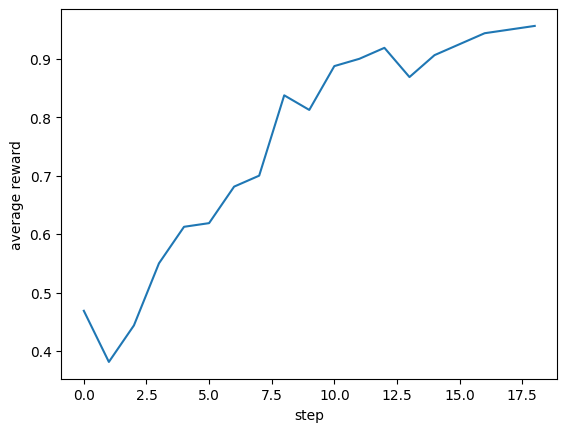

In [35]:
plt.plot(episode_mean_reward_history)
plt.xlabel('step')
plt.ylabel('average reward')